In [2]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.head())
print(df.info())
print(df.describe())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [4]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


Class Distribution (Before)

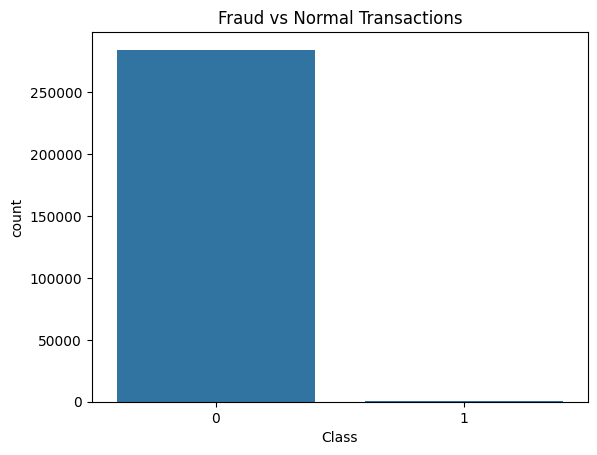

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

Subsampling

In [6]:
# Fraud data
fraud_df = df[df['Class'] == 1]

# Normal data
normal_df = df[df['Class'] == 0]

# Randomly sample normal data equal to fraud
normal_sample = normal_df.sample(n=len(fraud_df), random_state=42)  #without fraud will take same no.of rows as of fraud rowsand each time same rows as i am fixing the seed value

# Combine
new_df = pd.concat([fraud_df, normal_sample], axis=0)

# Shuffle
new_df = new_df.sample(frac=1, random_state=42)  #frac=1 → take 100% of data but in random order

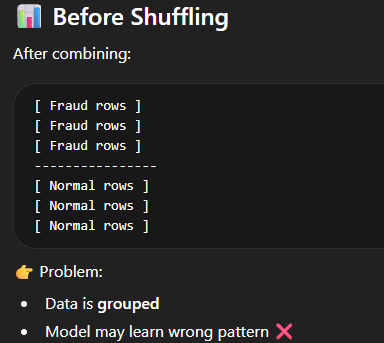

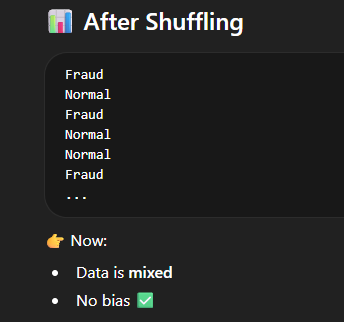

Class Distribution (After)

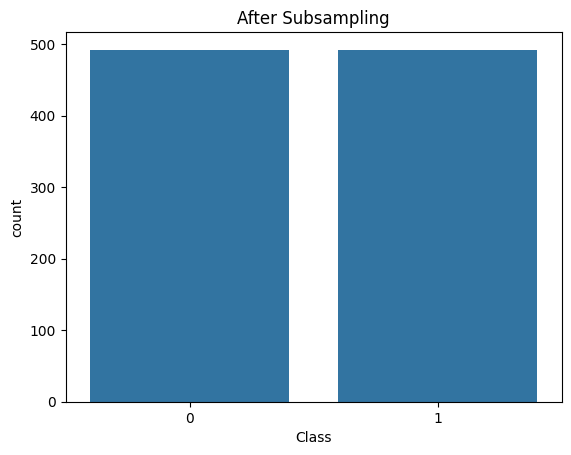

In [7]:
sns.countplot(x='Class', data=new_df)
plt.title("After Subsampling")
plt.show()

In [8]:
print("Total:", df['Amount'].describe())
print("Fraud:", df[df['Class']==1]['Amount'].describe())
print("Valid:", df[df['Class']==0]['Amount'].describe())

Total: count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
Fraud: count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
Valid: count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


Outlier Detection (IQR)

In [9]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]            #only outliers calculated in amt as it is rael data

print("Outliers:", len(outliers))

Outliers: 31904


In [10]:
fraud_count = df['Class'].value_counts()[1]
total_count = len(df)

fraud_percentage = (fraud_count / total_count) * 100

print("Fraud %:", fraud_percentage)

Fraud %: 0.1727485630620034


In [11]:
contamination = fraud_count / total_count
print("Contamination:", contamination)

Contamination: 0.001727485630620034


In [12]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.0017, random_state=42)

df['outlier'] = model.fit_predict(df[['Amount']])

outliers = df[df['outlier'] == -1]
print(outliers[['Amount']].head())
print("Number of outliers:", len(outliers))

print(df[df['outlier'] == -1]['Amount'].describe())

       Amount
164   3828.04
1632  7712.43
2178  3669.00
2453  2540.42
2622  2909.97
Number of outliers: 461
count      461.000000
mean      3809.354881
std       2040.221178
min       2466.800000
25%       2754.000000
50%       3291.000000
75%       4024.330000
max      25691.160000
Name: Amount, dtype: float64


Problem in your dataset

Your Amount is highly skewed (many small values, few large ones)

👉 So:

Upper limit becomes relatively low

Many large values get flagged

Meaning

IQR is saying:
“Anything far from middle = outlier”

👉 But in real life:

Many large transactions are NORMAL

So IQR over-detects ❌

Isolation Forest does NOT use fixed thresholds

👉 It checks:

How different a point is from others

Pattern, not just value

It finds truly unusual behavior, not just large values

why random_seed use in isolationforest?

Simple Example

Imagine:

You are finding suspicious people in a crowd 👥

🔹 Method 1 (IQR)

👉 Fixed rule:

“Anyone above ₹X is suspicious”

👉 Result:

SAME people every time ✅

🔹 Method 2 (Isolation Forest)

👉 Smart AI:

“Let me analyze behavior randomly in different ways”

👉 Result:

Slightly different suspects each time ❗

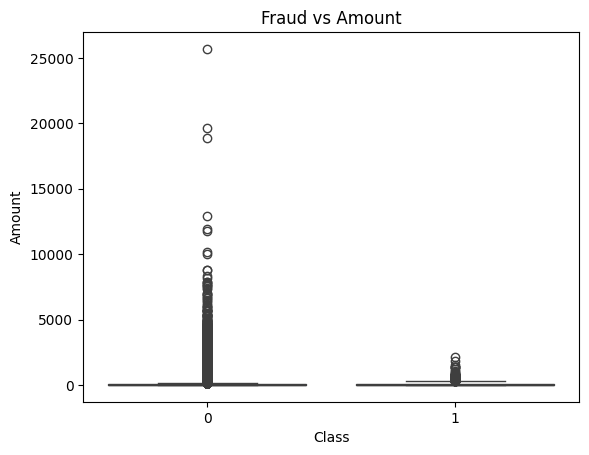

In [13]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Amount")
plt.show()

DBSCAN = Density-Based Spatial Clustering of Applications with Noise

It groups points that are close together and marks far-away points as outliers

# **code for dbscan(not used over here as the system is crashing)**

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Features
X = df[['Amount']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = db.fit_predict(X_scaled)

# Outliers
outliers = df[df['cluster'] == -1]

print("Number of outliers:", len(outliers))

Correlation Heatmap (Before)

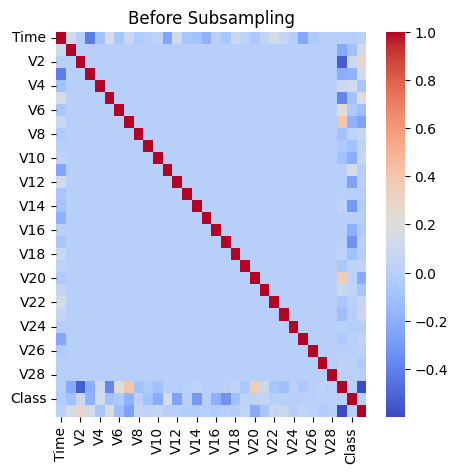

In [14]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Before Subsampling")
plt.show()

due to large no. of class 0 data, fraud data is almost hidden

Correlation Heatmap (After)

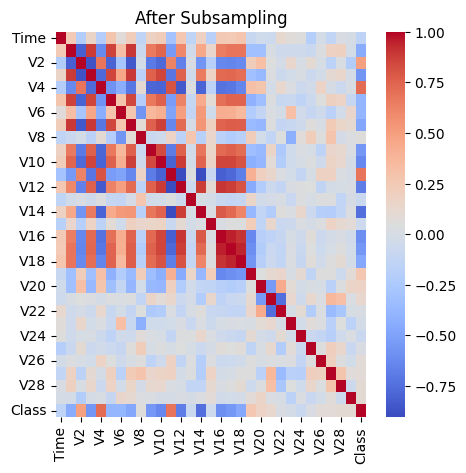

In [15]:
plt.figure(figsize=(5,5))
sns.heatmap(new_df.corr(), cmap='coolwarm')
plt.title("After Subsampling")
plt.show()

Correlation with Class

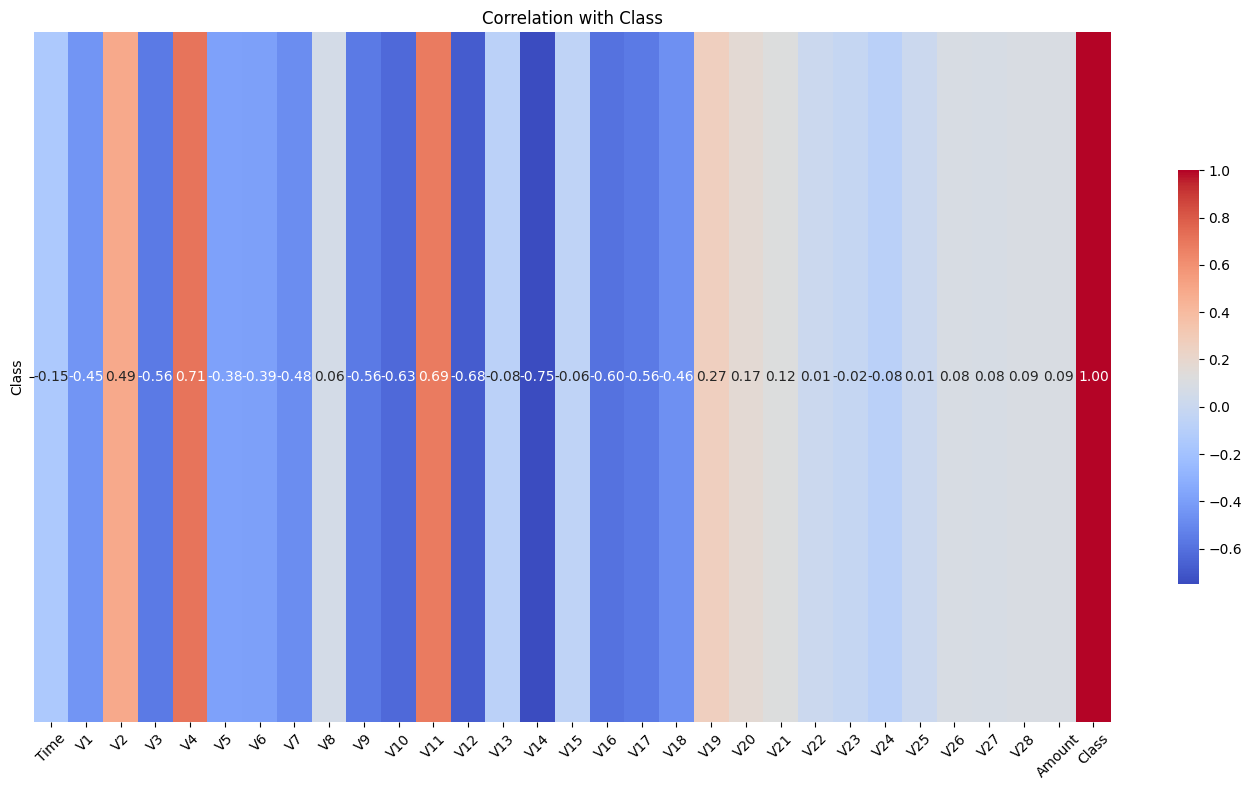

In [16]:
corr = new_df.corr()
class_corr = corr.loc['Class']

plt.figure(figsize=(14, 8))  # increase width, reduce height

sns.heatmap(
    class_corr.to_frame().T,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    cbar_kws={'shrink': 0.6}  # shrink color bar
)

plt.title("Correlation with Class")
plt.xticks(rotation=45)
plt.tight_layout()  # IMPORTANT
plt.show()

PCA Visualization

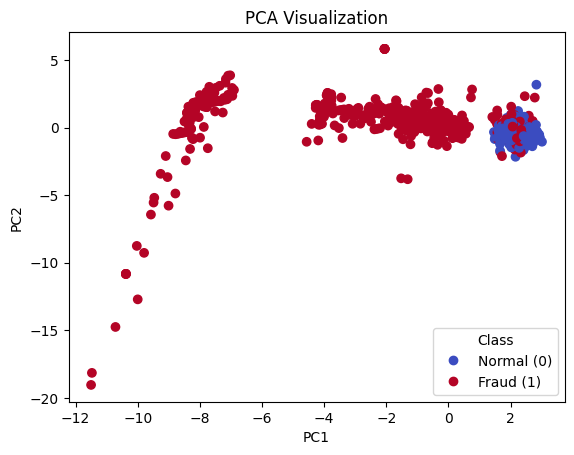

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = new_df.drop('Class', axis=1)   #keep all other cols and drop class col
y = new_df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter=plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')
plt.title("PCA Visualization")

handles, _ = scatter.legend_elements()
plt.legend(handles, ["Normal (0)", "Fraud (1)"], title="Class")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

t-SNE Visualization

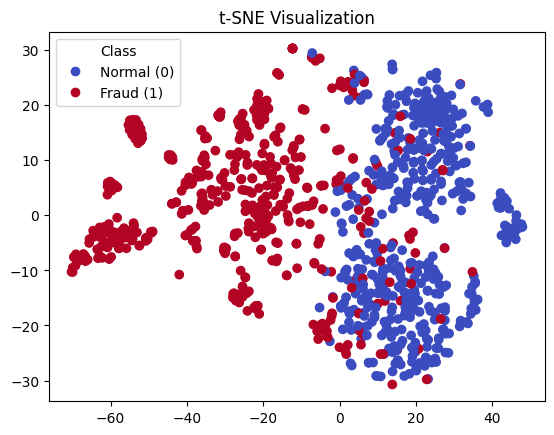

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

scatter=plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='coolwarm')

handles, _ = scatter.legend_elements()
plt.legend(handles, ["Normal (0)", "Fraud (1)"], title="Class")

plt.title("t-SNE Visualization")
plt.show()

t-SNE is spreading data to show hidden structure more clearly(data is clearly non-linear) based on that we will choose algorithm

In [19]:
from scipy.stats import ttest_ind

fraud = df[df['Class'] == 1]['Amount']
valid = df[df['Class'] == 0]['Amount']

t_stat, p_value = ttest_ind(fraud, valid)

print("P-value:", p_value)

# Hypothesis Decision
alpha = 0.05

print("\nHypothesis Testing Result:")

if p_value < alpha:
    print("Reject Null Hypothesis (H0)")
    print("Accept Alternative Hypothesis (H1)")
    print("Conclusion: Fraud and valid transaction amounts are significantly different.")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Reject Alternative Hypothesis (H1)")
    print("Conclusion: No significant difference between fraud and valid transaction amounts.")

P-value: 0.002651220649191683

Hypothesis Testing Result:
Reject Null Hypothesis (H0)
Accept Alternative Hypothesis (H1)
Conclusion: Fraud and valid transaction amounts are significantly different.


Accuracy: 0.999403110845827
Confusion Matrix:
 [[56846    18]
 [   16    82]]


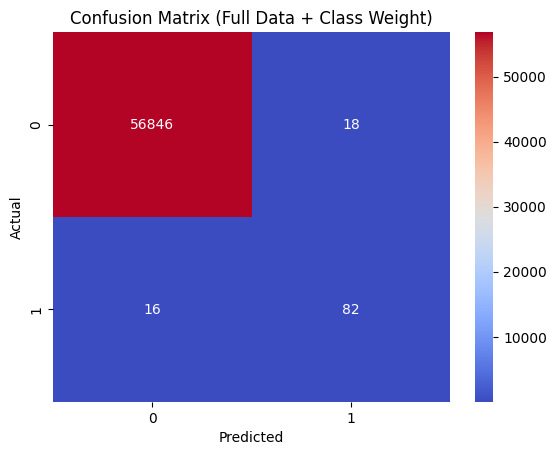

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("creditcard.csv")

# -----------------------------
# Features & Target
# -----------------------------
X = df.drop('Class', axis=1)
y = df['Class']

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)   #20% → testing, stratify=y-> Maintains same fraud ratio in train & test

# -----------------------------
# Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Handle Imbalance (IMPORTANT)
# -----------------------------
fraud = sum(y_train == 1)
normal = sum(y_train == 0)

scale_pos_weight = normal / fraud  #imbalance ratio(Tell model: fraud is rare but important)
#Normal = 284000
#Fraud = 492
#scale_pos_weight ≈ 577


# -----------------------------
# XGBoost Model
# -----------------------------
model = XGBClassifier(
    n_estimators=150,     #Number of trees → more trees = better learning (but slower)
    max_depth=5,          #depth of each tree handles complexity
    learning_rate=0.1,     #speed of learning -> smaller = more stable
    subsample=0.8,         #Uses 80% data per tree -> prevents overfitting
    colsample_bytree=0.8,   #Uses 80% features->adds randomness
    scale_pos_weight=scale_pos_weight,  # KEY LINE 🔥 #handles imbalance
    random_state=42,
    eval_metric='logloss'    #Log Loss measures how good your predicted probabilities are
)

# Train
model.fit(X_train, y_train)

# Predict
y_prob = model.predict_proba(X_test)[:,1]   #Get probability of fraud
y_pred = (y_prob > 0.7).astype(int)  #If probability > 0.7 → fraud, Else → normal

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix (Full Data + Class Weight)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

Precision = 0.82

👉 Out of all fraud predictions:

82% are actually fraud

👉 Very good ✅ (low false alarms)



Recall = 0.84

👉 Out of all actual fraud:

84% detected

👉 Good ✅ (few missed fraud)

In [21]:
for t in [0.3, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.87      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.85      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.6
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00   

Choose 0.7 if:

👉 You want:

Catch more fraud

🔹 Choose 0.8 if:

👉 You want:

Fewer false alarms

If recall is low

👉 You miss fraud:

Fraud happens → model says normal ❌

👉 Financial loss 💸

🎯 Why Precision also matters

Precision=
👉 Measures:

“How many flagged frauds are actually fraud?”

⚠️ If precision is low

👉 Too many false alarms:

Normal user → blocked ❌

👉 Bad customer experience 😡

⚖️ So what is ideal?

👉 NOT:

Recall >> Precision ❌ (too many false alarms)

👉 NOT:

Precision >> Recall ❌ (miss fraud)
✅ IDEAL
Recall slightly ≥ Precision

In [25]:
y_prob = model.predict_proba(X_test)[:,1]  # Probabilities

In [26]:
# ROC + AUC
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.9778490462026115


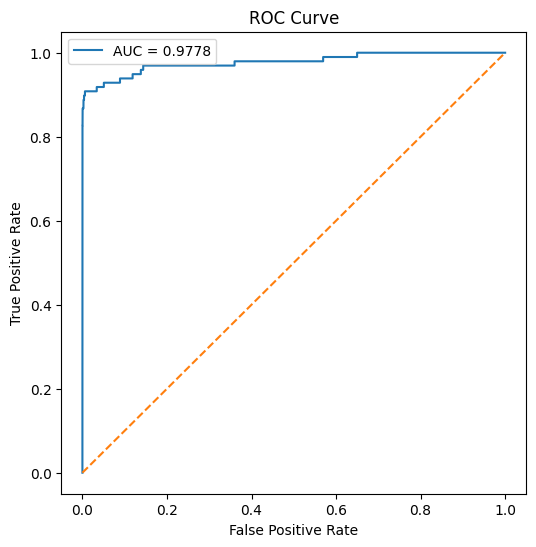

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

X-axis → False Positive Rate (FPR)
“Out of all normal transactions, how many were wrongly predicted as fraud?”

Y-axis → True Positive Rate (TPR / Recall)
Out of all fraud transactions, how many were correctly detected?

curve is:

Very close to top-left corner 🔥
🎯 What that means

High TPR (you catch fraud) ✅

Low FPR (few false alarms)

AUC is 0.97 so Model separates fraud and normal extremely well

Imagine only 6 transactions:

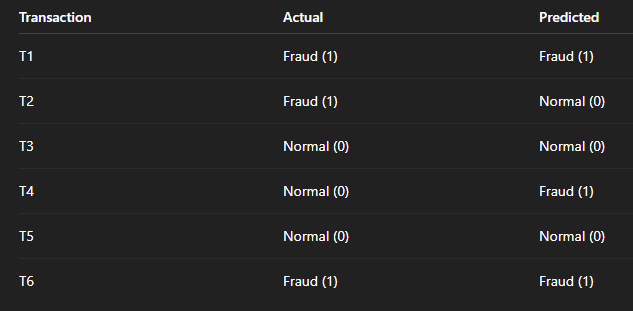


Now classify each case
🔹 Case 1: TP (True Positive)

👉 Actual = Fraud
👉 Predicted = Fraud

✔ Correct fraud detection

Example:

T1, T6
🔹 Case 2: FN (False Negative)

👉 Actual = Fraud
👉 Predicted = Normal

❌ Missed fraud (VERY BAD)

Example:

T2
🔹 Case 3: TN (True Negative)

👉 Actual = Normal
👉 Predicted = Normal

✔ Correct normal

Example:

T3, T5
🔹 Case 4: FP (False Positive)

👉 Actual = Normal
👉 Predicted = Fraud

❌ False alarm

Example:

T4

## **What we actually care about in classification**

We don’t care about “scattered or not”.

We care about:

✅ Can we separate the classes with a straight line (or simple boundary)?
🔹 Simple Visual Idea
Case 1: Linearly separable

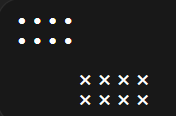

👉 You can draw a straight line between them

✔ Use:

Logistic Regression

Linear SVM

Case 2: Non-linear
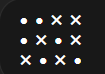

👉 Mixed / overlapping

❌ Straight line won’t work

✔ Use:

XGBoost

Random Forest

Neural Networks

🔹 Now your main question 👇
❓ Why PCA / t-SNE to check this?
🔹 Problem in real datasets

👉 Credit card dataset has:

30+ features (dimensions)

👉 Humans cannot visualize:

30D space 😵
🔹 So what we do
👉 Step 1: Reduce dimensions
✔ PCA
Linear reduction
Keeps major variance
✔ t-SNE
Non-linear reduction
Preserves local structure
🔹 Step 2: Plot in 2D

Now you can see:

Are fraud & non-fraud separated?
Or overlapping?
🔹 Step 3: Decide model type
👉 If PCA plot shows separation:

✔ Data is likely linearly separable
→ Use Logistic Regression

👉 If PCA fails but t-SNE shows clusters:

✔ Data has non-linear structure
→ Use XGBoost / RF